In [1]:
import os
import pandas as pd

In [3]:
RESULT_DIR = "./save_results"

for file in os.listdir(RESULT_DIR):
    print(file)
    if file.find("NN") != -1:
        print(file)

fully_supervised
weakly_supervised
semi_supervised


In [15]:
os.mkdir(os.path.join(RESULT_DIR, "weakly_supervised"))

In [16]:
target = os.path.join(RESULT_DIR, "weakly_supervised")
for file in os.listdir(RESULT_DIR):
    if file.startswith("wsl"):
        os.rename(os.path.join(RESULT_DIR, file), os.path.join(target, file))

In [4]:
def get_all_csv(directory: str) -> list[str]:
    res: list[str] = []
    for file in os.listdir(directory):
        if file.endswith(".csv"):
            res.append(os.path.join(directory, file))
        if os.path.isdir(os.path.join(directory, file)):
            res.extend(get_all_csv(os.path.join(directory, file)))
    return res

In [5]:
main_dirs : list[str] = ["/fully_supervised", "/semi_supervised", "/weakly_supervised"]
main_dirs = [RESULT_DIR + sub_dir for sub_dir in main_dirs]

In [6]:
print(get_all_csv((main_dirs[0])))

['./save_results/fully_supervised/VSS_Net_NN_260527_210416/VSS_Net_result.csv', './save_results/fully_supervised/Att_UNet_NN_260527_222210/Att_UNet_result.csv', './save_results/fully_supervised/FR_UNet_3D_NN_260528_094634/FR_UNet_3D_result.csv', './save_results/fully_supervised/CSNet_3D_NN_260528_122908/CSNet_3D_result.csv', './save_results/fully_supervised/UNet_Nested_NN_260528_000323/UNet_Nested_result.csv', './save_results/fully_supervised/Res_UNet_3D_NN_260528_182747/Res_UNet_3D_result.csv', './save_results/fully_supervised/Res_UNet_NN_260528_011013/Res_UNet_result.csv', './save_results/fully_supervised/ST_UNet_NN_260529_194151/ST_UNet_result.csv', './save_results/fully_supervised/UNet_NN_260529_175103/UNet_result.csv', './save_results/fully_supervised/MAA_Net_NN_260606_084342/MAA_Net_result.csv', './save_results/fully_supervised/IPN_NN_260606_041238/IPN_result.csv', './save_results/fully_supervised/PSC_NN_260528_220236/PSC_result.csv', './save_results/fully_supervised/FR_UNet_NN_2

In [15]:
from typing import cast


def create_accumulated_df(directory: str) -> pd.DataFrame:
    csvs: list[str] = get_all_csv(directory)
    df = pd.DataFrame()
    for path in csvs:
        csv_data: pd.DataFrame = cast(pd.DataFrame, pd.read_csv(path))
        csv_data.insert(0, "type", path.split("/")[-3] + "/" + path.split("/")[-2])
        df = pd.concat([csv_data, df], ignore_index=True)
    df = df.drop(labels="Unnamed: 0", axis=1)
    return df

In [16]:
create_accumulated_df(target).to_csv(f"{target}/consolidated.csv")

./save_results/semi_supervised/FR_UNet_260530_162356/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_1_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_1_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/i

ValueError: cannot insert type, already exists

In [10]:
for path in main_dirs:
    create_accumulated_df(path).to_csv(f"{path}/consolidated.csv")

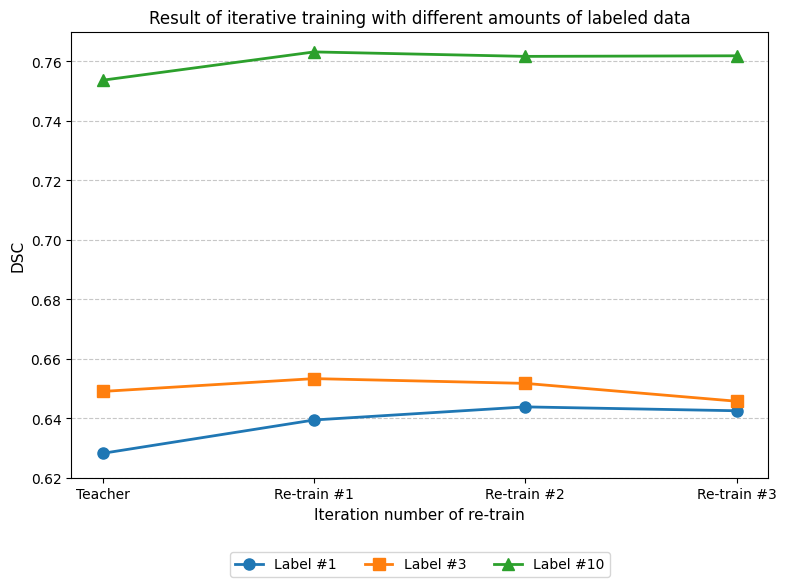

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('./save_results/semi_supervised/consolidated.csv')

# Mapping to the SDA + 60 unlabeled variants
run_mappings = {
    'Label #1': 'FR_UNet_260601_060734',   # 1_60_SDA
    'Label #3': 'FR_UNet_260602_020818',   # 3_60_SDA
    'Label #10': 'FR_UNet_260602_190000'   # 10_60_SDA
}

# The four stages shown in Figure 9
stages = ['ite_1_teacher', 'ite_1_student', 'ite_2_student', 'ite_3_student']
x_labels = ['Teacher', 'Re-train #1', 'Re-train #2', 'Re-train #3']

# Function to extract the mean DSC value
def get_dsc_mean(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str) and '$\pm$' in val:
        return float(val.split('$\pm$')[0])
    return float(val)

# 2. Extract the data for plotting
plot_data = {}

for label_name, run_id in run_mappings.items():
    dsc_values = []
    for stage in stages:
        target_type = f"{run_id}/{stage}"
        row = df[df['type'] == target_type]

        if not row.empty:
            raw_dsc = row.iloc[0]['DSC']
            dsc_values.append(get_dsc_mean(raw_dsc))
        else:
            dsc_values.append(np.nan)

    plot_data[label_name] = dsc_values

# use standard light color
plt.style.use('default')

# 3. Create the plot
plt.figure(figsize=(8, 6))

colors = {'Label #1': '#1f77b4', 'Label #3': '#ff7f0e', 'Label #10': '#2ca02c'}
markers = {'Label #1': 'o', 'Label #3': 's', 'Label #10': '^'}

for label_name, values in plot_data.items():
    plt.plot(x_labels, values, marker=markers[label_name], color=colors[label_name],
             linewidth=2, markersize=8, label=label_name)

# 4. Customize the plot to match the paper's style
plt.title('Result of iterative training with different amounts of labeled data', fontsize=12)
plt.xlabel('Iteration number of re-train', fontsize=11)
plt.ylabel('DSC', fontsize=11)

plt.ylim(0.62, 0.77)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Places it centered below the x-axis, spread across 3 columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Show and save the plot
plt.tight_layout()
plt.savefig('fig9_recreation.png', dpi=300)
plt.show()

In [30]:
"""
Recreate Figure 7 and Figure 8 from DIAS save_results/.

Both figures are labeled grids of pre-rendered error-overlay images
(the color_b{N}.png files: red = false neg, green = false pos,
 white/black = correct vessel/background). No plotting, just placement.

Requirements:  pip install matplotlib pillow
Usage:         set ROOT below, then `python make_figures.py`
               -> writes figure7.png and figure8.png

The samples used are b14 (Fig 7) and b17 (Fig 8), per request.
To match the paper's multi-row layout, add more sample ids to the
SAMPLES_* lists -- each id becomes one extra row.
"""

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ---------------------------------------------------------------------------
# Path to save_results, relative to where you run the script.
# You run from /DIAS and save_results/ sits directly under it:
ROOT = "save_results"
# which overlay to show. "color_b" = colored error map (what the paper uses).
# alternatives in each folder: "pre" (binary pred), "gt" (ground truth).
KIND = "color_b"
SAMPLES_FIG7 = [14, 17]   # each sample id becomes one row
SAMPLES_FIG8 = [14, 17]   # combined with RDFA/SALE -> rows per (sample, scheme)
# ---------------------------------------------------------------------------


def cell(folder, sample, kind=KIND, gray=False):
    """Path to one panel image, or None if missing (with a warning).
    If gray=True, returns (path, 'gray') so image_grid renders it grayscale."""
    if folder is None:
        return None
    p = os.path.join(folder, f"{kind}{sample}.png")
    if not os.path.exists(p):
        print("  MISSING:", p)
        return None
    return (p, "gray") if gray else p


def image_grid(rows, col_labels=None, row_labels=None, row_label_colors=None,
               out="figure.png", panel=1.5, dpi=300, fontsize=9):
    nrows = len(rows)
    ncols = max(len(r) for r in rows)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel * ncols, panel * nrows),
        gridspec_kw=dict(wspace=0.02, hspace=0.02),
        squeeze=False,
    )
    for i, row in enumerate(rows):
        for j in range(ncols):
            ax = axes[i][j]
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)
            path = row[j] if j < len(row) else None
            cmap = None
            if isinstance(path, tuple):       # (path, cmap) e.g. ("...gt14.png", "gray")
                path, cmap = path
            if path:
                img = mpimg.imread(path)
                # a gt mask saved as RGB(A) but visually grayscale: collapse to 1 channel
                if cmap == "gray" and img.ndim == 3:
                    img = img[..., :3].mean(axis=2)
                ax.imshow(img, cmap=cmap)
            ax.set_aspect("auto")
            if col_labels and i == nrows - 1 and j < len(col_labels):
                ax.set_xlabel(col_labels[j], fontsize=fontsize, labelpad=4)
            if row_labels and j == 0 and i < len(row_labels):
                color = row_label_colors[i] if row_label_colors else "none"
                ax.set_ylabel(
                    row_labels[i], fontsize=fontsize, rotation=90, labelpad=6,
                    bbox=(dict(facecolor=color, edgecolor="none",
                               boxstyle="round,pad=0.3")
                          if color != "none" else None),
                )
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("wrote", out)


# ---------------------------------------------------------------------------
# FIGURE 7 -- fully-supervised state-of-the-art comparison.
# (col label) -> (results sub-folder name)
# Column (a) "Image" reuses the ground-truth render gt{N}.png as the leftmost
# panel; swap to your raw DSA image folder if you have one.
# ---------------------------------------------------------------------------
FIG7_MODELS = [
    ("(a) Image",        "VSS_Net_NN_260615_092204"),  # leftmost: use gt as "image"
    ("(b) UNet++",       "UNet_Nested_NN_260528_000323"),
    ("(c) CS$^2$-Net",   "CSNet_NN_260527_231159"),
    ("(d) MAA-Net",      "MAA_Net_NN_260606_084342"),
    ("(e) FR-UNet",      "FR_UNet_NN_260529_184205"),
    ("(f) 3D UNet",      "UNet_3D_NN_260528_021342"),
    ("(g) 3D Res-UNet",  "Res_UNet_3D_NN_260528_182747"),
    ("(h) 3D CS$^2$-Net","CSNet_3D_NN_260528_122908"),
    ("(i) IPN",          "IPN_NN_260606_041238"),
    ("(j) PSC",          "PSC_NN_260528_220236"),
    ("(k) SVS-Net",      "SVS_Net_NN_260528_230109"),
    ("(l) ST-UNet",      "ST_UNet_NN_260529_194151"),
    ("(m) VSS-Net",      "VSS_Net_NN_260615_092204"),
]


def figure7():
    base = os.path.join(ROOT, "fully_supervised")
    cols = [lab for lab, _ in FIG7_MODELS]
    rows = []
    for s in SAMPLES_FIG7:
        row = []
        for k, (lab, folder) in enumerate(FIG7_MODELS):
            full = os.path.join(base, folder)
            if k == 0:
                # leftmost column = ground-truth mask, rendered grayscale
                row.append(cell(full, s, "gt", gray=True))
            else:
                row.append(cell(full, s, KIND))
        rows.append(row)
    image_grid(
        rows, col_labels=cols,
        row_labels=[f"#{s}" for s in SAMPLES_FIG7],
        out="figure7.png", panel=1.4,
    )


# ---------------------------------------------------------------------------
# FIGURE 8 -- weakly (scribble) supervised comparison.
# Paper rows = RDFA / SALE annotation variants. The dump has one folder per
# method; if you trained RDFA and SALE into separate runs, point each row's
# dict at the matching run. Here both rows reuse the same folders (single run).
# ---------------------------------------------------------------------------
# Each method folder contains TWO timestamped run subfolders, one per
# annotation scheme. Format: (label, method_folder, RDFA_run, SALE_run).
FIG8_MODELS = [
    ("(a) image", "wsl_train_pcedice",
     "UNet_RDFA_260603_193335",     "UNet_SALE_260604_110725"),     # gt source
    ("(b) pCE",   "wsl_train_pcedice",
     "UNet_RDFA_260603_193335",     "UNet_SALE_260604_110725"),
    ("(c) EM",    "wsl_train_entropy_mini",
     "UNet_RDFA_260603_210412",     "UNet_SALE_260604_124157"),
    ("(d) RLoss", "wsl_train_GatedCRFLoss",
     "UNet_RDFA_260603_223747",     "UNet_SALE_260604_141900"),
    ("(e) IVM",   "wsl_train_Inter&Intra_Class",
     "UNet_RDFA_260604_001144",     "UNet_SALE_260604_160148"),
    ("(f) DMPLS", "wsl_train_DMPLS",
     "UNet_CCT_RDFA_260606_185011", "UNet_CCT_SALE_260606_230638"),
    ("(g) SSCR",  "wsl_train_sscr",
     "UNet_RDFA_260604_014249",     "UNet_SALE_260605_022144"),
]


def figure8():
    base = os.path.join(ROOT, "weakly_supervised")
    cols = [m[0] for m in FIG8_MODELS]
    # scheme -> (label, bar color, run index in FIG8_MODELS tuple)
    schemes = [("RDFA", "#bcd9a6", 2), ("SALE", "#a9cce3", 3)]
    rows, row_labels, row_colors = [], [], []
    # outer loop = scheme, inner = sample  ->  rows: RDFA 14, RDFA 17, SALE 14, SALE 17
    for name, color, run_idx in schemes:
        for s in SAMPLES_FIG8:
            row = []
            for k, model in enumerate(FIG8_MODELS):
                full = os.path.join(base, model[1], model[run_idx])
                if k == 0:
                    row.append(cell(full, s, "gt", gray=True))
                else:
                    row.append(cell(full, s, KIND))
            rows.append(row)
            row_labels.append(f"{name} #{s}")
            row_colors.append(color)
    image_grid(
        rows, col_labels=cols,
        row_labels=row_labels, row_label_colors=row_colors,
        out="figure8.png", panel=1.7,
    )


if __name__ == "__main__":
    if not os.path.isdir(ROOT):
        raise SystemExit(
            f"ROOT not found: {os.path.abspath(ROOT)}\n"
            f"Run from /DIAS (so 'save_results' resolves), or edit ROOT."
        )
    figure7()
    # figure8()

wrote figure7.png
wrote figure8.png


In [1]:
"""
Semi-supervised comparison figures (NOT in the paper).

Produces TWO figures from the ite_1 STUDENT runs (teachers and later
iterations ignored, matching the table you built):

  figure_sda.png        -- SDA vs no-SDA, restricted to settings that exist
                           with BOTH sda on and off (same L and U), so each
                           pair differs only in SDA. Pairs sit on adjacent
                           rows.
  figure_unlabeled.png  -- among SDA runs only, the effect of the number of
                           unlabeled images (U), for each labeled budget (L)
                           that was run at more than one U. Sorted L then U.

Each row is one run's ite_1_student error overlay for a few test samples
(COLUMNS: yellow=FP, blue=FN, white=TP). DSC is read live from the CSV.

Requirements:  pip install matplotlib pillow
Run from /DIAS:  python make_semi_figure.py
"""

import os
import csv
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ---------------------------------------------------------------------------
ROOT = "save_results"
SEMI_DIR = os.path.join(ROOT, "semi_supervised")
CSV_PATH = os.path.join(SEMI_DIR, "consolidated.csv")   # consolidated table you made
ITE = "ite_1_student"          # student only, first iteration (as requested)
KIND = "color_b"               # error overlay (yellow=FP, blue=FN, white=TP)
SAMPLES = [14, 15]             # which test-sample columns to show
# ---------------------------------------------------------------------------

# Fill in what you know for each run.  None -> row skipped.
#   sda          : True / False
#   n_label      : number of labeled images used
#   n_unlabel    : number of unlabeled images used
# (ite_1_student DSC from the CSV is shown for reference in the comments.)
# Filled in from saved_models/semi_supervised/, where the parent folder name
# encodes the config: "{n_label}_{n_unlabel}[_SDA]".  ite_1_student DSC shown
# for reference; it's still read live from the CSV, these are just notes.
RUN_META = {
    # no-SDA runs
    "FR_UNet_260531_205724": dict(sda=False, n_label=1,  n_unlabel=60),  # 1_60       DSC 0.4925
    "FR_UNet_260601_161037": dict(sda=False, n_label=3,  n_unlabel=60),  # 3_60       DSC 0.4531
    "FR_UNet_260602_094212": dict(sda=False, n_label=10, n_unlabel=60),  # 10_60      DSC 0.5839
    # SDA runs
    "FR_UNet_260530_043833": dict(sda=True,  n_label=1,  n_unlabel=30),  # 1_30_SDA   DSC 0.5905
    "FR_UNet_260601_060734": dict(sda=True,  n_label=1,  n_unlabel=60),  # 1_60_SDA   DSC 0.6395
    "FR_UNet_260530_162356": dict(sda=True,  n_label=3,  n_unlabel=30),  # 3_30_SDA   DSC 0.6415
    "FR_UNet_260602_020818": dict(sda=True,  n_label=3,  n_unlabel=60),  # 3_60_SDA   DSC 0.6534
    "FR_UNet_260531_074329": dict(sda=True,  n_label=10, n_unlabel=30),  # 10_30_SDA  DSC 0.7500
    "FR_UNet_260602_190000": dict(sda=True,  n_label=10, n_unlabel=60),  # 10_60_SDA  DSC 0.7632
}


def load_dsc():
    """run -> ite_1_student DSC (float), from the consolidated CSV."""
    out = {}
    with open(CSV_PATH) as f:
        for r in csv.DictReader(f):
            t = r["type"]
            if t.endswith(ITE):
                run = t.split("/")[0]
                try:
                    out[run] = float(r["DSC"].split("$")[0])
                except ValueError:
                    pass
    return out


def cell(folder, sample, kind=KIND, gray=False):
    if folder is None:
        return None
    p = os.path.join(folder, f"{kind}{sample}.png")
    if not os.path.exists(p):
        print("  MISSING:", p)
        return None
    return (p, "gray") if gray else p


def image_grid(rows, col_labels=None, row_labels=None, row_label_colors=None,
               out="figure.png", panel=1.6, dpi=300, fontsize=8):
    nrows = len(rows)
    ncols = max(len(r) for r in rows)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel * ncols + 1.4, panel * nrows),
        gridspec_kw=dict(wspace=0.02, hspace=0.02),
        squeeze=False,
    )
    for i, row in enumerate(rows):
        for j in range(ncols):
            ax = axes[i][j]
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)
            path = row[j] if j < len(row) else None
            cmap = None
            if isinstance(path, tuple):
                path, cmap = path
            if path:
                img = mpimg.imread(path)
                if cmap == "gray" and img.ndim == 3:
                    img = img[..., :3].mean(axis=2)
                ax.imshow(img, cmap=cmap)
            ax.set_aspect("auto")
            if col_labels and i == nrows - 1 and j < len(col_labels):
                ax.set_xlabel(col_labels[j], fontsize=fontsize, labelpad=4)
            if row_labels and j == 0 and i < len(row_labels):
                color = row_label_colors[i] if row_label_colors else "none"
                ax.set_ylabel(
                    row_labels[i], fontsize=fontsize, rotation=0,
                    ha="right", va="center", labelpad=10,
                    color="white" if color != "none" else "black",
                    bbox=(dict(facecolor=color, edgecolor="none",
                               boxstyle="round,pad=0.35")
                          if color != "none" else None),
                )
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("wrote", out)


def _build(runs, out, color_fn, panel=1.6):
    """Shared row-builder. The very top row shows the ground truth for every
    sample (black label). Each run below is one row of its predictions, one
    column per sample. DSC read from CSV; `color_fn(meta) -> hex` sets each
    model row's label color."""
    dsc = load_dsc()
    cols = [f"sample #{s}" for s in SAMPLES]
    gt_base = os.path.join(SEMI_DIR, runs[0][0], ITE)

    rows, row_labels, row_colors = [], [], []

    # --- top row: ground truth for each sample
    rows.append([cell(gt_base, s, "gt", gray=True) for s in SAMPLES])
    row_labels.append("ground truth")
    row_colors.append("#000000")        # black label

    # --- one row per run: predictions
    for run, m in runs:
        base = os.path.join(SEMI_DIR, run, ITE)
        rows.append([cell(base, s, KIND) for s in SAMPLES])
        sda_txt = "SDA" if m["sda"] else "no-SDA"
        d = dsc.get(run)
        d_txt = f"DSC {d:.4f}" if d is not None else "DSC ?"
        row_labels.append(
            f"{sda_txt}\nL={m['n_label']}  U={m.get('n_unlabel','?')}\n{d_txt}"
        )
        row_colors.append(color_fn(m))

    image_grid(rows, col_labels=cols, row_labels=row_labels,
               row_label_colors=row_colors, out=out, panel=panel)


def annotated():
    runs = [(r, m) for r, m in RUN_META.items()
            if m.get("sda") is not None and m.get("n_label") is not None]
    if not runs:
        raise SystemExit(
            "RUN_META is empty -- fill in sda / n_label / n_unlabel."
        )
    return runs


def figure_sda():
    """FIGURE A: SDA vs no-SDA. Only the matched settings that exist with
    BOTH sda=True and sda=False (same L and U) -- otherwise it isn't a clean
    toggle. Rows sorted so each no-SDA/SDA pair is adjacent."""
    runs = annotated()
    # find (L,U) settings that have both an SDA and a no-SDA run
    have = {}
    for r, m in runs:
        have.setdefault((m["n_label"], m["n_unlabel"]), set()).add(m["sda"])
    matched = {lu for lu, flags in have.items() if {True, False} <= flags}
    sel = [(r, m) for r, m in runs
           if (m["n_label"], m["n_unlabel"]) in matched]
    sel.sort(key=lambda rm: (rm[1]["n_label"], rm[1]["n_unlabel"], rm[1]["sda"]))
    if not sel:
        print("figure_sda: no matched SDA/no-SDA pairs found -- skipping.")
        return
    # no-SDA = dark blue, SDA = a lighter green
    color_fn = lambda m: "#3f9b4f" if m["sda"] else "#1f3a6b"
    _build(sel, out="figure_sda.png", color_fn=color_fn)


def figure_unlabeled():
    """FIGURE B: among SDA runs only, the effect of the unlabeled-image count.
    Keep L values that appear with more than one U, sort by L then U so the
    U=30 -> U=60 progression reads down within each label budget."""
    runs = [(r, m) for r, m in annotated() if m["sda"]]
    us_per_l = {}
    for r, m in runs:
        us_per_l.setdefault(m["n_label"], set()).add(m["n_unlabel"])
    varying = {l for l, us in us_per_l.items() if len(us) > 1}
    sel = [(r, m) for r, m in runs if m["n_label"] in varying]
    sel.sort(key=lambda rm: (rm[1]["n_label"], rm[1]["n_unlabel"]))
    if not sel:
        print("figure_unlabeled: no SDA runs with varying U -- skipping.")
        return
    # color by unlabeled count: U=60 vs U=30 (all rows are SDA here)
    color_fn = lambda m: "#3f9b4f" if m.get("n_unlabel") == 60 else "#1f3a6b"
    _build(sel, out="figure_unlabeled.png", color_fn=color_fn)


if __name__ == "__main__":
    if not os.path.isdir(SEMI_DIR):
        raise SystemExit(
            f"not found: {os.path.abspath(SEMI_DIR)}\n"
            f"Run from /DIAS so 'save_results/semi_supervised' resolves."
        )
    figure_sda()
    figure_unlabeled()

wrote figure_sda.png
wrote figure_unlabeled.png
